# Autoencoder for Image Denoising on MNIST

We build a convolutional autoencoder that takes a noisy MNIST image and reconstructs the clean version.
The encoder compresses the image into a smaller representation, and the decoder rebuilds it back.

In [1]:
# !pip install tensorflow numpy matplotlib

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Load and Normalize Data

MNIST has 60,000 training and 10,000 test grayscale images of size 28x28.
We normalize pixel values to the range 0-1 and reshape for the CNN.

In [3]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]
print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape : (10000, 28, 28, 1)


## Add Noise

We add random Gaussian noise to the images to simulate corrupted input.
The noisy images are what the model receives as input. The clean images are what it tries to reconstruct.

In [4]:
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.randn(*x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.randn(*x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0)
print("Noisy train shape:", x_train_noisy.shape)

Noisy train shape: (60000, 28, 28, 1)


## Visualize Clean vs Noisy

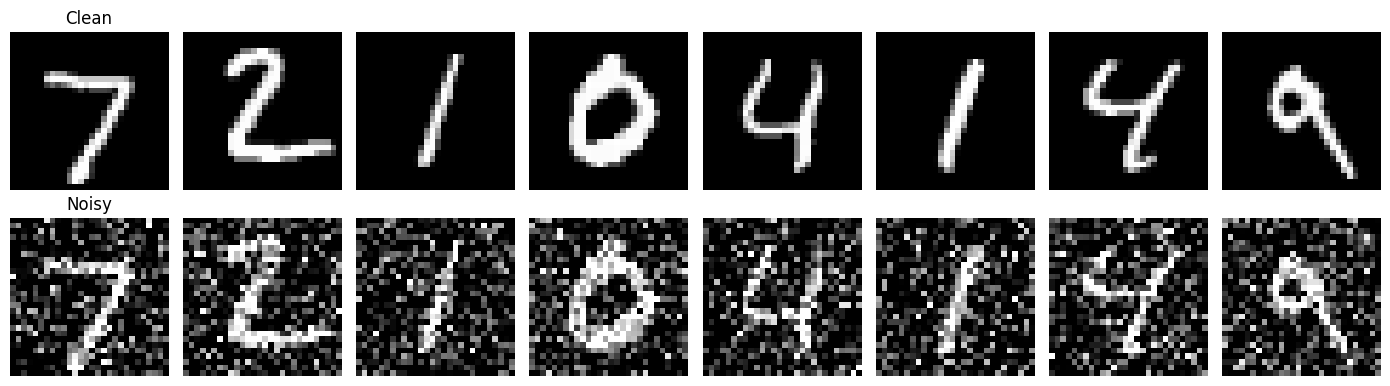

In [5]:
n = 8
plt.figure(figsize=(14, 4))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title('Clean' if i == 0 else '')
    plt.axis('off')
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title('Noisy' if i == 0 else '')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Build the Autoencoder

The encoder uses Conv2D layers to compress the image down.
The decoder uses Conv2DTranspose layers to upsample back to the original 28x28 size.
The final layer uses sigmoid so output values stay between 0 and 1, matching the input range.

In [6]:
def build_autoencoder():
    inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)       
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x) 
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)                  
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)                     
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    model = models.Model(inputs, decoded, name='Autoencoder')
    return model

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Train

Input is the noisy image, target is the clean image.
We use MSE loss since we are comparing pixel values, not class probabilities.

In [7]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.1456 - val_loss: 0.0990
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0965 - val_loss: 0.0929
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0924 - val_loss: 0.0902
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0903 - val_loss: 0.0889
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0891 - val_loss: 0.0880
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0882 - val_loss: 0.0880
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0875 - val_loss: 0.0866
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0869 - val_loss: 0.0859
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0864 - val_loss: 0.0856
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0860 - val_loss: 0.0852
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0856 - val_loss: 0.0850
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 

## Training Loss

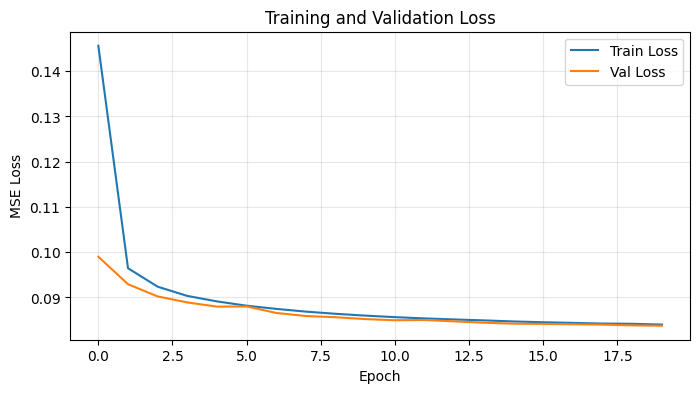

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Results — Original vs Noisy vs Reconstructed

This is the main output. We pass noisy images through the trained autoencoder and compare the result with the original clean image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


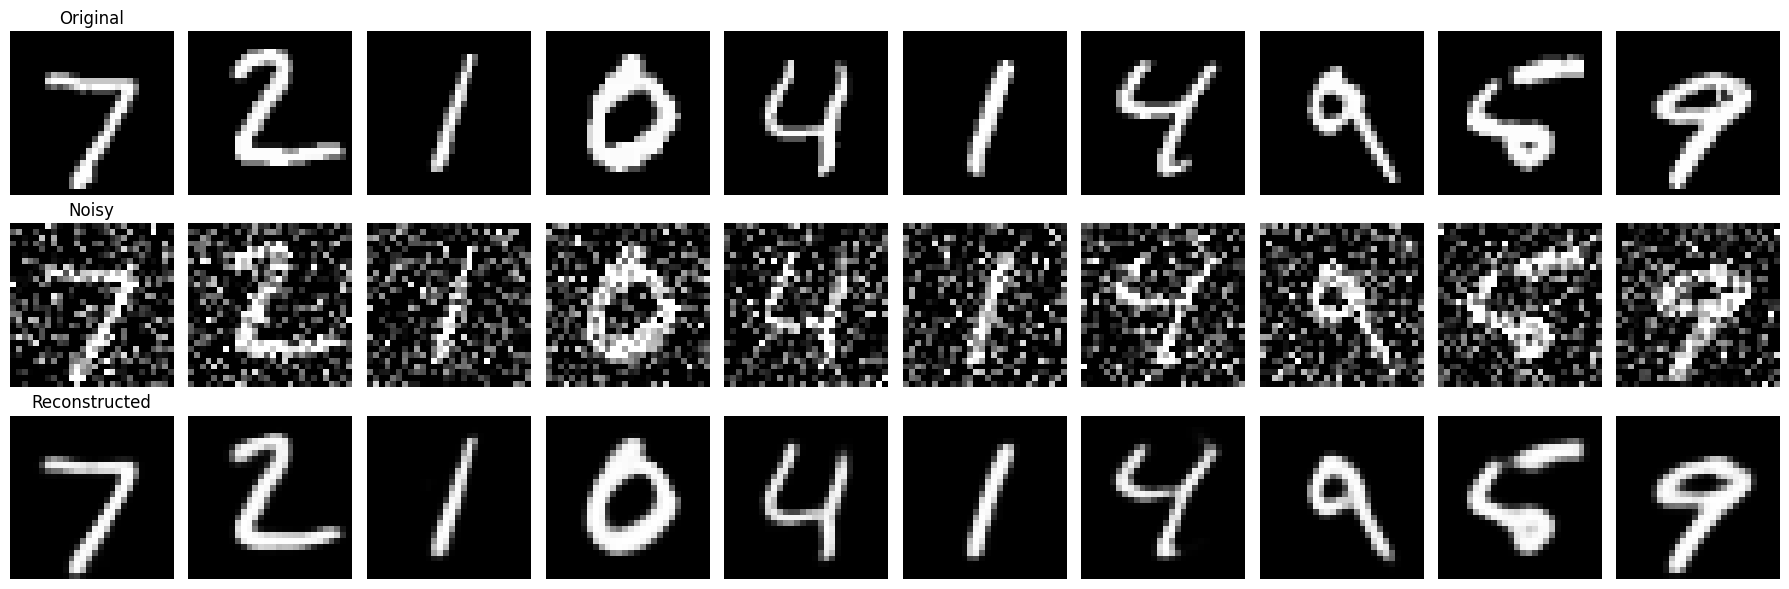

In [9]:
reconstructed = autoencoder.predict(x_test_noisy[:10])
n = 10
plt.figure(figsize=(18, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.title('Original' if i == 0 else '')
    plt.axis('off')
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.title('Noisy' if i == 0 else '')
    plt.axis('off')
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(reconstructed[i].squeeze(), cmap='gray')
    plt.title('Reconstructed' if i == 0 else '')
    plt.axis('off')

plt.tight_layout()
plt.show()